In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import os, sys
from astropy.io import fits
import healpy as hp

from scipy.interpolate import interp1d
from scipy.optimize import minimize, shgo
from scipy.stats import poisson
from scipy import signal

sys.path.append('..')

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file('../notebooks/matplotlibrc')

In [3]:
from utils.cart import to_cart
from utils.data_processing import get_GC_data, downsample

## 1. counts

### 1.1 counts 573/718 week

In [4]:
#tag = '573weeks'
tag = '718weeks'

DIR = f'/zfs/tslatyer/fermidata/exposure/pass8_{tag}'
if tag == '573weeks':
    counts_fn = f'{DIR}/ccube_ultracleanveto_bestpsf_halfsky1.fits'
    exposure_fn = f'{DIR}/exposure-ultracleanveto-bestpsf.fits'
elif tag == '718weeks':
    counts_fn = f'{DIR}/ccube_ultracleanveto_bestpsf_joined.fits'
    exposure_fn = f'{DIR}/exposure_ultracleanveto_bestpsf_joined.fits'

## 1. counts
with fits.open(counts_fn) as hdul:
    
    extent_counts = 20
    pixel_size_target = 0.5
    pixel_size_data = np.abs(hdul[0].header['CDELT1'])
    downsample_f = int(pixel_size_target/pixel_size_data)
    print(f'counts:\npixel_size_data={pixel_size_data}')

    eng_ind_start = np.searchsorted(hdul[1].data['E_MIN'], 2e6) # 2e6 keV
    eng_ind_endp1 = np.searchsorted(hdul[1].data['E_MIN'], 2e7) # 20e6 keV
    print(f'eng: [{eng_ind_start}:{eng_ind_endp1}]')

    counts_cube = get_GC_data(hdul[0], extent_counts, verbose=True)[eng_ind_start:eng_ind_endp1]
    counts = downsample(np.sum(counts_cube, axis=0), downsample_f, verbose=True)
    print(f'total count={np.sum(counts)}')

    np.save(f'data/fermidata/counts_{tag}.npy', counts)
    
## 2. exposure
with fits.open(exposure_fn) as hdul:
    
    extent_exposure = 25
    pixel_size_target = 0.5
    pixel_size_data = np.abs(hdul[0].header['CDELT1'])
    downsample_f = int(pixel_size_target/pixel_size_data)
    print(f'exposure:\npixel_size_data={pixel_size_data}')
    
    eng_ind_start = np.searchsorted(hdul[1].data['ENERGY'], 2e3) # 2e3 MeV
    eng_ind_endp1 = np.searchsorted(hdul[1].data['ENERGY'], 2e4) # 20e3 MeV
    print(f'eng: [{eng_ind_start}:{eng_ind_endp1}]')

    exposure_raw = get_GC_data(hdul[0], extent_exposure, verbose=True)[eng_ind_start:eng_ind_endp1]
    exposure = np.array([downsample(exp, downsample_f, verbose=(i==0)) for i, exp in enumerate(exposure_raw)])
    
    np.save(f'data/fermidata/exposure_{tag}.npy', exposure)
    
    exposure_plot = exposure[0]

counts:
pixel_size_data=0.1
eng: [40:50]
get_GC_data: l: [700:1100]
get_GC_data: b: [700:1100]
downsample: shape:(400,400) -> (80,80)
total count=362612
exposure:
pixel_size_data=0.1
eng: [40:50]
get_GC_data: l: [650:1150]
get_GC_data: b: [650:1150]
downsample: shape:(500,500) -> (100,100)


### 1.2 counts & exposure Jun19 (for comparison)

In [5]:
tag = 'Jun19'
extent_counts = 20
extent_exposure = 25

counts_healpix = np.load('data/fermidata/counts_Jun19_NSIDE512.npy')
counts = to_cart(counts_healpix, n_pixels=80, pixelsize=0.5, offset=(0.5, -0.5))

exposure_healpix = np.load('data/fermidata/exposure_Jun19_NSIDE512.npy')
exposure = to_cart(exposure_healpix, n_pixels=100, pixelsize=0.5, offset=(0.5, -0.5))

exposure_plot = exposure

### 1.3 plot

/zfs/yitians/anaconda3/envs/fermi/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: divide by zero encountered in log10
  


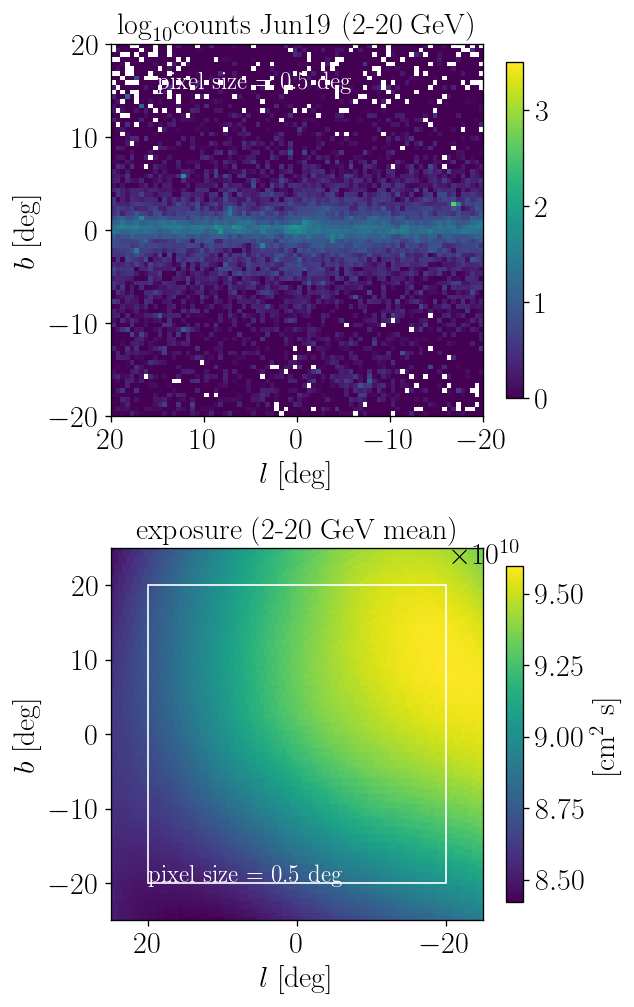

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(5, 10))
im0 = axs[0].imshow(np.log10(counts), vmin=0, vmax=3.5, extent=(extent_counts, -extent_counts, -extent_counts, extent_counts))
axs[0].set(title='$\log_{10}$counts %s (2-20 GeV)' % tag, xlabel='$l$ [deg]', ylabel='$b$ [deg]')
axs[0].text(15, 15, f'pixel size = {pixel_size_target} deg', color='w', fontsize=14)
fig.colorbar(im0, ax=axs[0], shrink=0.8);

exposure_title = f'exposure {tag} (2 GeV)' if 'week' in tag else 'exposure (2-20 GeV mean)'

im1 = axs[1].imshow(exposure_plot, extent=(extent_exposure, -extent_exposure, -extent_exposure, extent_exposure))
axs[1].set(title=exposure_title, xlabel='$l$ [deg]', ylabel='$b$ [deg]')
axs[1].text(20, -20, f'pixel size = {pixel_size_target} deg', color='w', fontsize=14)
axs[1].add_patch(mpl.patches.Rectangle((-20, -20), 40, 40, fc=(0,0,0,0), ec='w'))
fig.colorbar(im1, ax=axs[1], shrink=0.8, label='[cm$^2$ s]');

## 2. flux comparison

In [41]:
flux573 = np.load('data/fermidata/counts_573week.npy') / np.sum(np.load('data/fermidata/exposure_573week.npy')[:, 10:90,10:90], axis=0)
flux718 = np.load('data/fermidata/counts_718week.npy') / np.sum(np.load('data/fermidata/exposure_718week.npy')[:, 10:90,10:90], axis=0)

/zfs/yitians/anaconda3/envs/fermi/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in true_divide
  


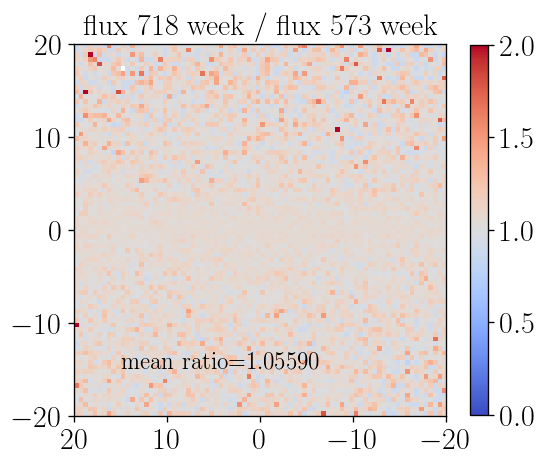

In [52]:
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(flux718/flux573, extent=(20,-20,-20,20), cmap='coolwarm', vmin=0, vmax=2)
ax.text(15, -15, f'mean ratio={np.sum(flux718)/np.sum(flux573):.5f}', fontsize=14)
ax.set(title='flux 718 week / flux 573 week')
fig.colorbar(im, shrink=0.8)